**Seeding for reproducibility**

In [1]:
import tensorflow as tf


In [2]:
# Set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

**Importing the dependencies**

In [3]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

**GPU Configuration**

In [4]:
!python -m pip install --upgrade pip

In [5]:
pip install tensorflow-directml

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-directml (from versions: none)
ERROR: No matching distribution found for tensorflow-directml


**Data Curation**

Upload the kaggle.json file

In [6]:
!pip install kaggle

In [7]:
kaggle_credentails = json.load(open("kaggle.json"))

In [8]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [9]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p .

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0




  0%|          | 0.00/2.04G [00:00<?, ?B/s]
  0%|          | 1.00M/2.04G [00:01<54:51, 665kB/s]
  0%|          | 2.00M/2.04G [00:01<27:13, 1.34MB/s]
  0%|          | 3.00M/2.04G [00:01<16:55, 2.15MB/s]
  0%|          | 5.00M/2.04G [00:02<09:28, 3.84MB/s]
  0%|          | 6.00M/2.04G [00:02<07:57, 4.58MB/s]
  0%|          | 7.00M/2.04G [00:02<06:39, 5.46MB/s]
  0%|          | 9.00M/2.04G [00:02<05:07, 7.09MB/s]
  1%|          | 11.0M/2.04G [00:02<04:24, 8.22MB/s]
  1%|          | 13.0M/2.04G [00:02<03:58, 9.12MB/s]
  1%|          | 15.0M/2.04G [00:03<03:44, 9.67MB/s]
  1%|          | 17.0M/2.04G [00:03<03:33, 10.2MB/s]
  1%|          | 19.0M/2.04G [00:03<03:26, 10.5MB/s]
  1%|          | 21.0M/2.04G [00:03<03:25, 10.5MB/s]
  1%|          | 23.0M/2.04G [00:03<03:22, 10.7MB/s]
  1%|          | 25.0M/2.04G [00:04<03:17, 11.0MB/s]
  1%|▏         | 27.0M/2.04G [00:04<03:19, 10.9MB/s]
  1%|▏         | 29.0M/2.04G [00:04<03:18, 10.9MB/s]
  1%|▏         | 31.0M/2.04G [00:04<03:17, 10.9MB/s]
  

In [10]:
from zipfile import ZipFile

with ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

**Number of Classes = 38**

**Data Preprocessing**

In [11]:
# Dataset Path
base_dir = "plantvillage dataset/color"

In [12]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'grayscale', 'segmented']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [13]:
print(len(os.listdir("plantvillage dataset/color/Apple___healthy")))
print(os.listdir("plantvillage dataset/color/Apple___healthy")[:5])

1645
['0055dd26-23a7-4415-ac61-e0b44ebfaf80___RS_HL 5672.JPG', '00907d8b-6ae6-4306-bfd7-d54471981a86___RS_HL 5709.JPG', '0098dbd9-286a-4d6a-bf4b-5459d66f88c0___RS_HL 5776.JPG', '00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG', '00fca0da-2db3-481b-b98a-9b67bb7b105c___RS_HL 7708.JPG']


In [14]:
# Image Parameters
img_size = 224
batch_size = 32

**Train Test Split**

In [15]:
# Image Data Generators with Enhanced Augmentation
from tensorflow.keras.applications.resnet50 import preprocess_input

data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [18]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical',
     shuffle=True

)

Found 43456 images belonging to 38 classes.


In [19]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
     shuffle=True
)

Found 10849 images belonging to 38 classes.


**Convolutional Neural Network**

In [20]:
# Model Definition using Transfer Learning (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # Freeze base layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [21]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,151,078 (92.13 MB)

 Trainable params: 562,854 (2.15 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [22]:
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Model training**

In [25]:
history = model.fit(
    train_generator,
     steps_per_epoch=train_generator.samples // batch_size,
    epochs=11,
    validation_data=validation_generator,
     validation_steps=validation_generator.samples // batch_size ,
    callbacks=[early_stop]
)

Epoch 1/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 6035s 4s/step - accuracy: 0.6351 - loss: 1.3947 - val_accuracy: 0.9056 - val_loss: 0.3780
Epoch 2/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 3333s 2s/step - accuracy: 0.8561 - loss: 0.5001 - val_accuracy: 0.9467 - val_loss: 0.1925
Epoch 3/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 6358s 5s/step - accuracy: 0.8996 - loss: 0.3285 - val_accuracy: 0.9608 - val_loss: 0.1339
Epoch 4/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2154s 2s/step - accuracy: 0.9214 - loss: 0.2532 - val_accuracy: 0.9686 - val_loss: 0.1085
Epoch 5/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1634s 1s/step - accuracy: 0.9326 - loss: 0.2155 - val_accuracy: 0.9688 - val_loss: 0.0945
Epoch 6/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1621s 1s/step - accuracy: 0.9418 - loss: 0.1866 - val_accuracy: 0.9742 - val_loss: 0.0845
Epoch 7/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1665s 1s/step - accuracy: 0.9462 - loss: 0.1667 - val_accuracy: 0.9760 - val_loss: 0.0773
Epoch 8/11
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1627s 1s/step - accuracy: 0.9520 -

**Model Evaluation**

In [26]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 325s 959ms/step - accuracy: 0.9802 - loss: 0.0567
Validation Accuracy: 98.02%


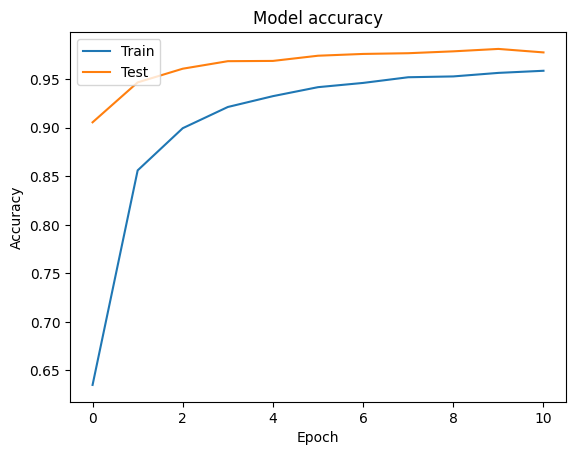

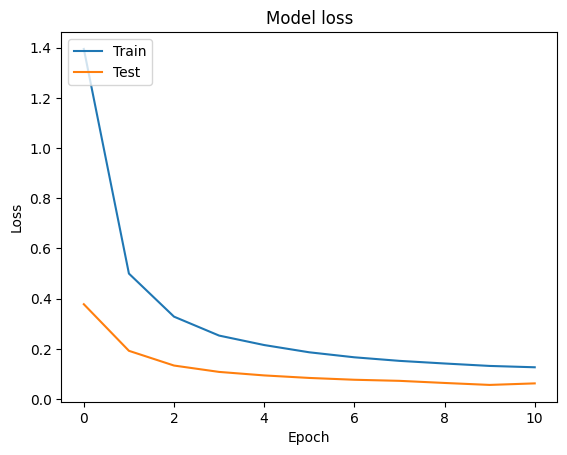

In [27]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

**Building a Predictive System**

**Save the model to Google drive or local**

In [31]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [32]:
class_indices
     

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [40]:
json.dump(class_indices, open("../app/class_indices.json", "w"))

In [38]:
model.save("../app/trained_model/plant_disease_prediction_model2.h5")

In [42]:
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score
import numpy as np

# Create evaluation generator (IMPORTANT: shuffle=False)
validation_generator_eval = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
    shuffle=False
)

# Reset generator
validation_generator_eval.reset()

# True labels
y_true = validation_generator_eval.classes

# Predictions
y_pred_probs = model.predict(validation_generator_eval, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# Print results
print("===== Overall Metrics =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Detailed classification report
print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred, target_names=list(validation_generator_eval.class_indices.keys())))

Found 10849 images belonging to 38 classes.
340/340 ━━━━━━━━━━━━━━━━━━━━ 457s 1s/step
===== Overall Metrics =====
Accuracy: 0.9796
Precision (Macro): 0.9741
Recall (Macro): 0.9711
F1 Score (Macro): 0.9724
Precision (Weighted): 0.9796
Recall (Weighted): 0.9796
F1 Score (Weighted): 0.9795

===== Classification Report =====
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.98      0.97       126
                                 Apple___Black_rot       0.98      1.00      0.99       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(includi

In [44]:
!pip install seaborn

340/340 ━━━━━━━━━━━━━━━━━━━━ 312s 918ms/step


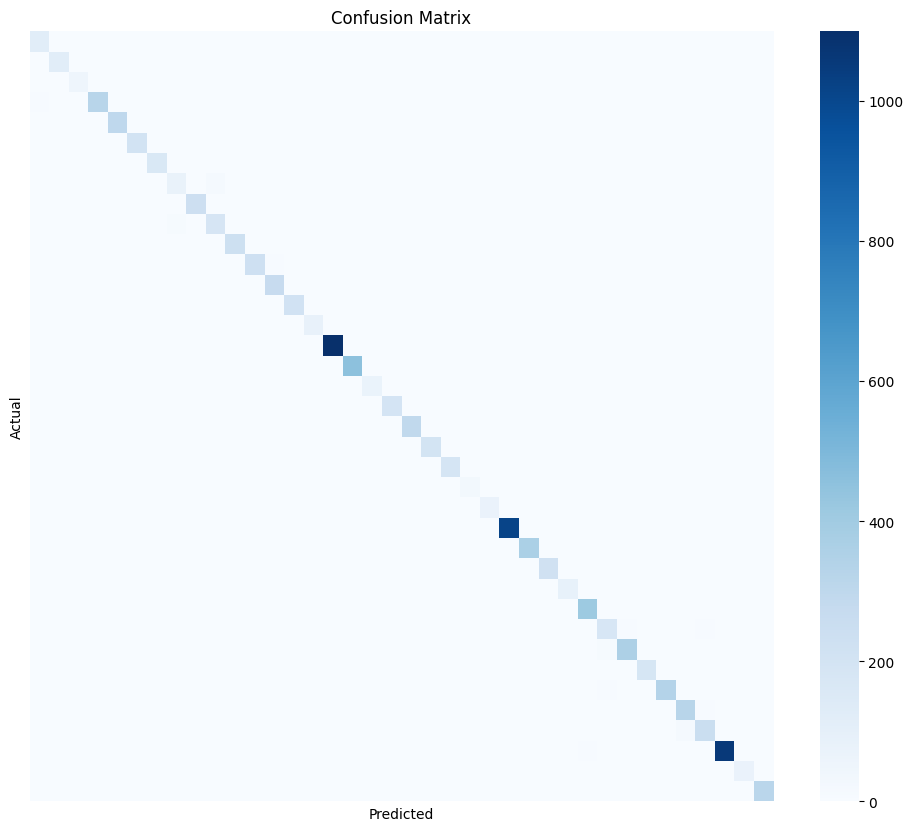

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Use evaluation generator (shuffle=False)
validation_generator_eval.reset()

y_true = validation_generator_eval.classes
y_pred_probs = model.predict(validation_generator_eval)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()